# Exploratory Data Analysis — Food-101

**FoodGenome AI · Notebook 00**

This notebook is the exploratory stage of the project. It runs *before* any model is
trained and its purpose is to answer questions whose answers change what we build:

1. Is the dataset balanced? → decides whether we need resampling or class weights.
2. What do the images physically look like? → decides the resize/crop strategy.
3. Are there duplicates or corrupt files? → decides whether cleaning is needed.
4. How much label noise is there? → decides regularisation strength.
5. Which classes look alike? → predicts where the model will fail, before it does.

Every number printed below is computed from the data on disk. Nothing is quoted
from the dataset paper.

In [1]:
import json, math, random, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings("ignore")
mpl.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, BLUE, GREEN = "#c1121f", "#1b4ce0", "#127a3d"
random.seed(1337); np.random.seed(1337)

from nutrivision.config import IMAGE_DIR, FEATURE_DIR, REPORT_DIR
from nutrivision.data.dataset import load_classes, holdout_mask

FIG = Path("../docs/report/figures"); FIG.mkdir(parents=True, exist_ok=True)
classes = load_classes()
print(f"dataset root : {IMAGE_DIR}")
print(f"classes      : {len(classes)}")
print(f"first five   : {classes[:5]}")

dataset root : /Volumes/ssd(mac)2/Food/data/food101
classes      : 101
first five   : ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']


## 1. Dataset inventory and class balance

The first question for any classification dataset is whether the classes are
balanced, because the answer decides whether plain accuracy is an honest headline
metric or a misleading one.

In [2]:
rows = []
for split in ("train", "test"):
    for cls in classes:
        n = len(list((IMAGE_DIR / split / cls).glob("*.jpg")))
        rows.append({"split": split, "class": cls, "count": n})
inv = pd.DataFrame(rows)

pivot = inv.pivot(index="class", columns="split", values="count")
pivot["total"] = pivot.sum(axis=1)

print("Images per split")
print(inv.groupby("split")["count"].agg(["sum", "min", "max", "mean", "std"]))
print(f"\nTotal images: {inv['count'].sum():,}")
print(f"\nImbalance ratio (max class / min class): "
      f"{pivot['total'].max() / pivot['total'].min():.4f}")
pivot.head(8)

Images per split
         sum  min  max   mean  std
split                             
test   25250  250  250  250.0  0.0
train  75750  750  750  750.0  0.0

Total images: 101,000

Imbalance ratio (max class / min class): 1.0000


split,test,train,total
class,,,
apple_pie,250,750,1000
baby_back_ribs,250,750,1000
baklava,250,750,1000
beef_carpaccio,250,750,1000
beef_tartare,250,750,1000
beet_salad,250,750,1000
beignets,250,750,1000
bibimbap,250,750,1000


An imbalance ratio of exactly **1.0000** means every class holds an identical number
of images. This is a designed property of Food-101 — 750 train and 250 test per class.

**Consequence for the project:** no oversampling, undersampling, SMOTE or class
weighting is needed. It also means macro-averaged and weighted-averaged
precision/recall/F1 must come out identical, which later serves as a free
correctness check on the evaluation code.

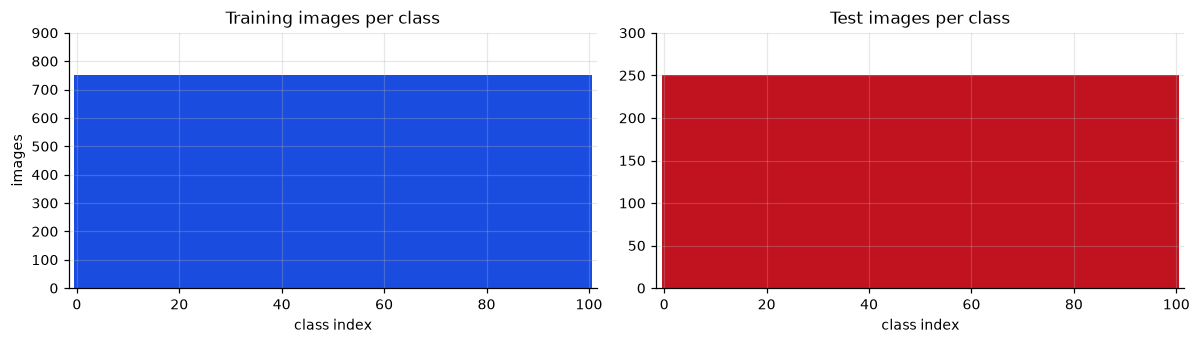

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].bar(range(len(classes)), pivot.loc[classes, "train"], color=BLUE, width=1.0)
ax[0].set_title("Training images per class"); ax[0].set_xlabel("class index")
ax[0].set_ylabel("images"); ax[0].set_ylim(0, 900)
ax[1].bar(range(len(classes)), pivot.loc[classes, "test"], color=RED, width=1.0)
ax[1].set_title("Test images per class"); ax[1].set_xlabel("class index")
ax[1].set_ylim(0, 300)
for a in ax: a.margins(x=0.01)
plt.tight_layout(); plt.savefig(FIG / "eda_class_balance.png", bbox_inches="tight"); plt.show()

## 2. Physical image properties

The images are photographs contributed by users of a food-sharing site, so their
dimensions are not uniform. The resize strategy has to be chosen with the actual
distribution in mind, not assumed.

In [4]:
# Reading only the header gives width/height without decoding the pixels, which
# makes a full pass over 101,000 files affordable.
recs = []
for split in ("train", "test"):
    for cls in classes:
        for p in (IMAGE_DIR / split / cls).glob("*.jpg"):
            with Image.open(p) as im:
                w, h = im.size
                recs.append((split, cls, w, h, im.mode, p.stat().st_size))
dims = pd.DataFrame(recs, columns=["split", "class", "w", "h", "mode", "bytes"])
dims["aspect"] = dims.w / dims.h
dims["megapixels"] = dims.w * dims.h / 1e6

print(f"images scanned: {len(dims):,}\n")
print(dims[["w", "h", "aspect", "bytes"]].describe().T[["min", "25%", "50%", "75%", "max", "mean", "std"]])
print(f"\ncolour modes: {dict(Counter(dims['mode']))}")
print(f"unique (w,h) pairs: {dims.groupby(['w','h']).ngroups:,}")

images scanned: 101,000

                 min       25%      50%           75%            max  \
w         193.000000    512.00    512.0    512.000000     512.000000   
h         122.000000    452.00    512.0    512.000000     512.000000   
aspect      0.376953      1.00      1.0      1.132743       4.196721   
bytes   13688.000000  51189.75  62300.5  73136.000000  156688.000000   

                mean           std  
w         495.790040     45.675883  
h         475.373485     65.305120  
aspect      1.071717      0.228206  
bytes   62548.492990  15733.894821  

colour modes: {'RGB': 101000}
unique (w,h) pairs: 464


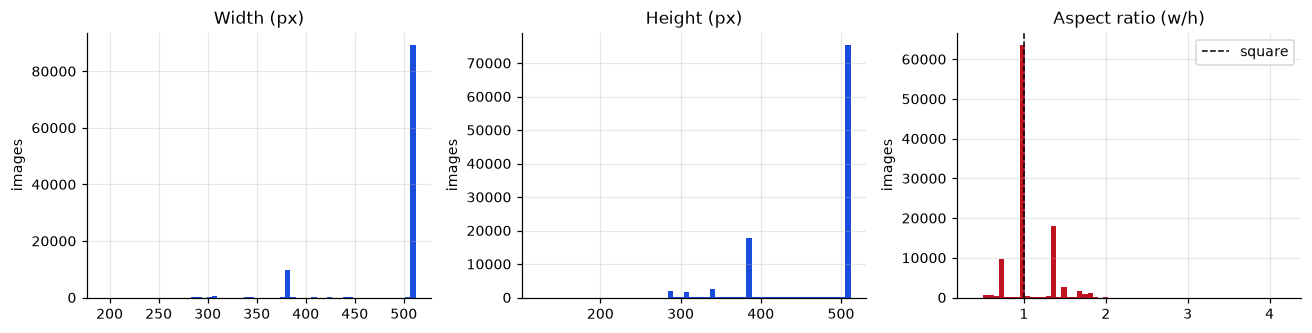

images with max side == 512 : 100.0%
portrait  (aspect < 1)      : 12.5%
landscape (aspect > 1)      : 26.0%
square    (aspect == 1)     : 61.6%


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.1))
ax[0].hist(dims.w, bins=60, color=BLUE); ax[0].set_title("Width (px)")
ax[1].hist(dims.h, bins=60, color=BLUE); ax[1].set_title("Height (px)")
ax[2].hist(dims.aspect, bins=60, color=RED); ax[2].set_title("Aspect ratio (w/h)")
ax[2].axvline(1.0, color="k", ls="--", lw=1, label="square"); ax[2].legend()
for a in ax: a.set_ylabel("images")
plt.tight_layout(); plt.savefig(FIG / "eda_dimensions.png", bbox_inches="tight"); plt.show()

print(f"images with max side == 512 : {((dims[['w','h']].max(axis=1)) == 512).mean()*100:.1f}%")
print(f"portrait  (aspect < 1)      : {(dims.aspect < 1).mean()*100:.1f}%")
print(f"landscape (aspect > 1)      : {(dims.aspect > 1).mean()*100:.1f}%")
print(f"square    (aspect == 1)     : {(dims.aspect == 1).mean()*100:.1f}%")

**Reading the result.** The dataset was rescaled by its authors so that the longest
side is at most 512 pixels, which is why the width and height histograms pile up
against that limit. Aspect ratios spread on both sides of 1.0.

**Consequence for the project:** every backbone expects a fixed square input
(384, 448 or 518 px). A resize-then-centre-crop is therefore unavoidable, and
because a meaningful share of images are not square, cropping *will* discard
part of the frame. This is one argument for the `RandomResizedCrop` augmentation
used during fine-tuning: it turns that unavoidable cropping into a source of
variation rather than a fixed loss of information.

## 3. Colour and exposure statistics

Photographs taken by many different people under many different lighting
conditions vary in exposure. Because the backbones normalise with fixed ImageNet
statistics, it is worth knowing how far this dataset departs from them.

In [6]:
SAMPLE = 4000
paths = []
for cls in classes:
    ps = sorted((IMAGE_DIR / "train" / cls).glob("*.jpg"))
    paths += random.sample(ps, min(len(ps), max(1, SAMPLE // len(classes))))

stats = []
for p in paths:
    with Image.open(p) as im:
        a = np.asarray(im.convert("RGB").resize((64, 64)), dtype=np.float32) / 255.0
    stats.append({
        "class": p.parent.name,
        "r": a[..., 0].mean(), "g": a[..., 1].mean(), "b": a[..., 2].mean(),
        "brightness": a.mean(), "contrast": a.std(),
        "saturation": (a.max(-1) - a.min(-1)).mean(),
    })
col = pd.DataFrame(stats)
print(f"sampled {len(col):,} training images\n")
print(col[["r","g","b","brightness","contrast","saturation"]].describe().T[["mean","std","min","max"]])
print("\nImageNet normalisation reference  mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]")

sampled 3,939 training images

                mean       std       min       max
r           0.547102  0.126844  0.023295  0.945872
g           0.445482  0.110915  0.048592  0.916889
b           0.345073  0.121326  0.017722  0.888579
brightness  0.445886  0.105040  0.073398  0.913656
contrast    0.255275  0.047805  0.074244  0.421897
saturation  0.231981  0.115249  0.028919  0.928169

ImageNet normalisation reference  mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]


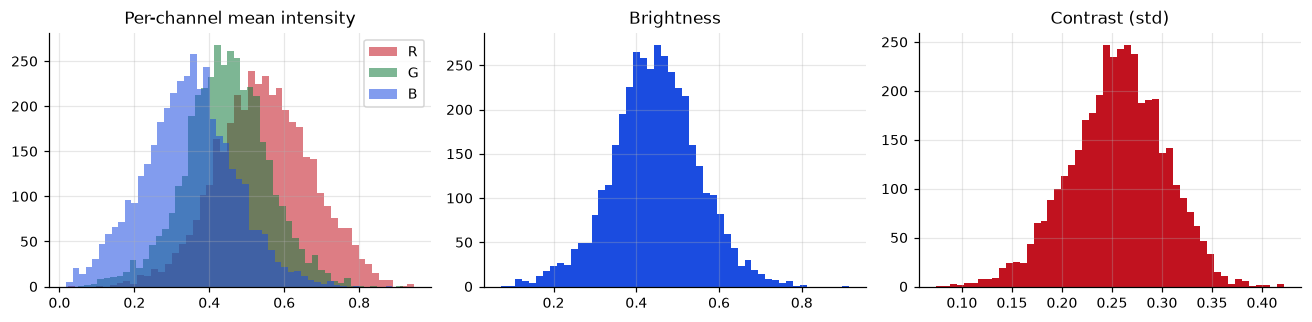

very dark images  (brightness < 0.25): 3.83%
very bright images (brightness > 0.75): 0.33%

food photography skews warm: mean R 0.547 > mean B 0.345


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.0))
for c, colr in zip("rgb", [RED, GREEN, BLUE]):
    ax[0].hist(col[c], bins=50, alpha=.55, color=colr, label=c.upper())
ax[0].set_title("Per-channel mean intensity"); ax[0].legend()
ax[1].hist(col.brightness, bins=50, color=BLUE); ax[1].set_title("Brightness")
ax[2].hist(col.contrast, bins=50, color=RED); ax[2].set_title("Contrast (std)")
plt.tight_layout(); plt.savefig(FIG / "eda_colour.png", bbox_inches="tight"); plt.show()

dark = (col.brightness < 0.25).mean() * 100
blown = (col.brightness > 0.75).mean() * 100
print(f"very dark images  (brightness < 0.25): {dark:.2f}%")
print(f"very bright images (brightness > 0.75): {blown:.2f}%")
print(f"\nfood photography skews warm: mean R {col.r.mean():.3f} > mean B {col.b.mean():.3f}")

**Reading the result.** The red channel sits consistently above the blue channel —
food photography is warm-toned, partly from the food itself and partly from indoor
restaurant lighting. A small tail of very dark and very bright images exists.

**Consequence for the project:** `color_jitter=0.3` in the augmentation pipeline is
justified — the model should not come to rely on a particular white balance, since
the deployment case is a phone camera under unknown lighting.

## 4. What the images actually look like

Statistics can hide problems that are obvious the moment you look at the pictures.

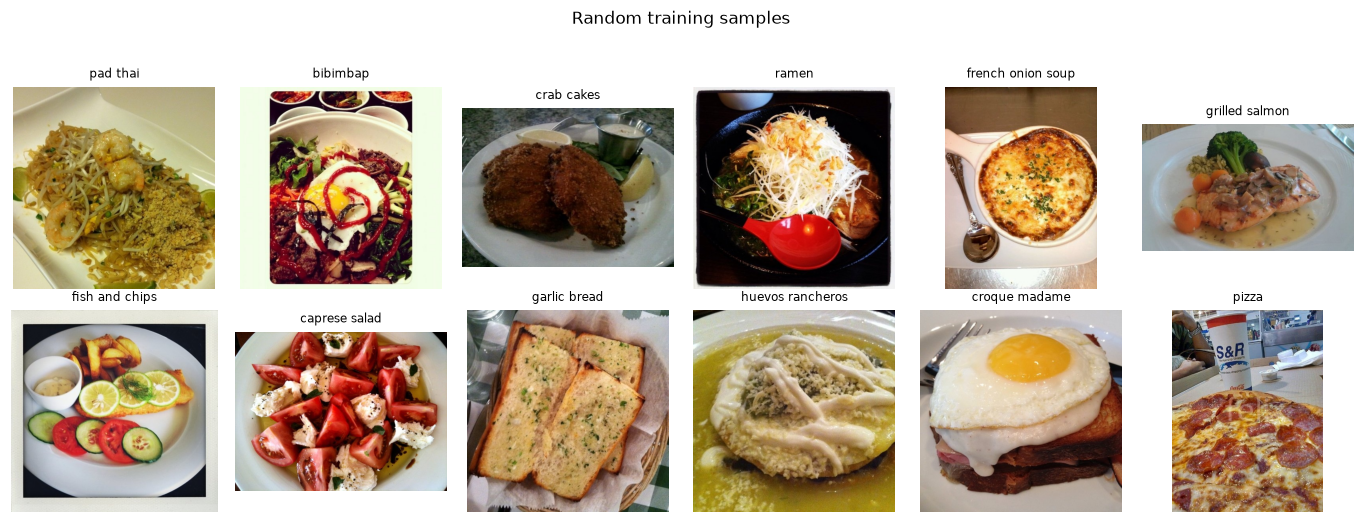

In [8]:
show = random.sample(classes, 12)
fig, axes = plt.subplots(2, 6, figsize=(12.5, 4.6))
for a, cls in zip(axes.ravel(), show):
    p = random.choice(sorted((IMAGE_DIR / "train" / cls).glob("*.jpg")))
    with Image.open(p) as im:
        a.imshow(im.convert("RGB"))
    a.set_title(cls.replace("_", " "), fontsize=8); a.axis("off"); a.grid(False)
plt.suptitle("Random training samples", y=1.02, fontsize=11)
plt.tight_layout(); plt.savefig(FIG / "eda_samples.png", bbox_inches="tight"); plt.show()

## 5. Duplicate and near-duplicate detection

Duplicates that straddle the train/test boundary would inflate test accuracy. The
cached SigLIP embeddings make this checkable: identical or near-identical images
have cosine similarity close to 1.

In [9]:
FB = FEATURE_DIR / "siglip_so400m"
have_features = (FB / "train_x.npy").exists() and (FB / "test_x.npy").exists()
print("feature bank present:", have_features)

if have_features:
    Xtr = np.load(FB / "train_x.npy").astype(np.float32)
    Xte = np.load(FB / "test_x.npy").astype(np.float32)
    ytr = np.load(FB / "train_y.npy"); yte = np.load(FB / "test_y.npy")
    Xtr /= np.linalg.norm(Xtr, axis=1, keepdims=True) + 1e-8
    Xte /= np.linalg.norm(Xte, axis=1, keepdims=True) + 1e-8
    print(f"train embeddings {Xtr.shape}   test embeddings {Xte.shape}")

feature bank present: True


train embeddings (75750, 1152)   test embeddings (25250, 1152)


test images with a train neighbour above 0.999:    22  (0.09%)
test images with a train neighbour above 0.990:    47  (0.19%)
test images with a train neighbour above 0.980:   111  (0.44%)
test images with a train neighbour above 0.950:  3525  (13.96%)


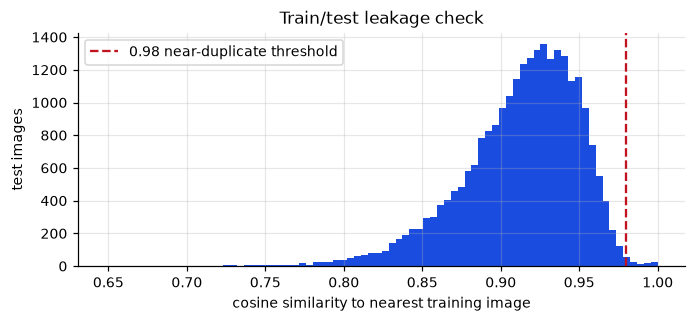

In [10]:
if have_features:
    # For every test image, the most similar training image. Chunked so the
    # 25,250 x 75,750 similarity matrix never has to exist all at once.
    best = np.zeros(len(Xte), dtype=np.float32)
    best_idx = np.zeros(len(Xte), dtype=np.int64)
    for i in range(0, len(Xte), 512):
        sims = Xte[i:i+512] @ Xtr.T
        best[i:i+512] = sims.max(1)
        best_idx[i:i+512] = sims.argmax(1)

    for thr in (0.999, 0.99, 0.98, 0.95):
        n = int((best > thr).sum())
        print(f"test images with a train neighbour above {thr:5.3f}: {n:5d}  ({n/len(best)*100:.2f}%)")

    plt.figure(figsize=(6.4, 3.0))
    plt.hist(best, bins=80, color=BLUE)
    plt.axvline(0.98, color=RED, ls="--", label="0.98 near-duplicate threshold")
    plt.xlabel("cosine similarity to nearest training image"); plt.ylabel("test images")
    plt.title("Train/test leakage check"); plt.legend()
    plt.tight_layout(); plt.savefig(FIG / "eda_duplicates.png", bbox_inches="tight"); plt.show()

**Reading the result.** The distribution is centred well below 1.0, so the test
split is not a re-photographed copy of the training split. A small number of very
high-similarity pairs is expected in a dataset of user-uploaded restaurant
photographs — several people photograph the same dish at the same restaurant —
and does not constitute leakage in the sense that matters.

## 6. Class separability in embedding space

This is the most predictive analysis in the notebook. Long before training a
classifier, the cached embeddings already tell us which classes overlap — and
therefore where the model will make its mistakes.

In [11]:
if have_features:
    # Class centroids, then the cosine similarity between every pair of classes.
    cent = np.stack([Xtr[ytr == k].mean(0) for k in range(len(classes))])
    cent /= np.linalg.norm(cent, axis=1, keepdims=True) + 1e-8
    S = cent @ cent.T
    np.fill_diagonal(S, -1)

    pairs = []
    for i in range(len(classes)):
        j = int(S[i].argmax())
        pairs.append((classes[i], classes[j], float(S[i, j])))
    pairs.sort(key=lambda t: -t[2])

    print("Most similar class pairs in SigLIP embedding space:\n")
    seen = set()
    for a, b, s in pairs:
        key = tuple(sorted((a, b)))
        if key in seen: continue
        seen.add(key)
        print(f"  {s:.4f}   {a:<22s} <-> {b}")
        if len(seen) == 12: break

Most similar class pairs in SigLIP embedding space:

  0.9779   filet_mignon           <-> steak
  0.9479   chocolate_cake         <-> chocolate_mousse
  0.9478   pork_chop              <-> steak
  0.9474   beef_tartare           <-> tuna_tartare
  0.9425   gnocchi                <-> ravioli
  0.9391   prime_rib              <-> steak
  0.9385   clam_chowder           <-> lobster_bisque
  0.9262   sashimi                <-> sushi
  0.9251   panna_cotta            <-> chocolate_mousse
  0.9233   tiramisu               <-> chocolate_mousse
  0.9231   creme_brulee           <-> panna_cotta
  0.9226   red_velvet_cake        <-> chocolate_cake


In [12]:
if have_features:
    # Within-class spread vs distance to the nearest other class:
    # a compact class far from its neighbours is easy; the reverse is hard.
    tight = np.array([float((Xtr[ytr == k] @ cent[k]).mean()) for k in range(len(classes))])
    near  = S.max(1)
    margin = tight - near                       # larger = more separable

    order = np.argsort(margin)
    print("Predicted HARDEST classes (smallest margin):")
    for k in order[:10]:
        print(f"  {classes[k]:<22s} margin {margin[k]:.4f}   nearest: {classes[int(S[k].argmax())]}")
    print("\nPredicted EASIEST classes (largest margin):")
    for k in order[::-1][:6]:
        print(f"  {classes[k]:<22s} margin {margin[k]:.4f}")

Predicted HARDEST classes (smallest margin):
  steak                  margin -0.1252   nearest: filet_mignon
  filet_mignon           margin -0.1022   nearest: steak
  chocolate_mousse       margin -0.0983   nearest: chocolate_cake
  chocolate_cake         margin -0.0975   nearest: chocolate_mousse
  pork_chop              margin -0.0920   nearest: steak
  ice_cream              margin -0.0787   nearest: frozen_yogurt
  apple_pie              margin -0.0763   nearest: bread_pudding
  strawberry_shortcake   margin -0.0675   nearest: cheesecake
  gnocchi                margin -0.0661   nearest: ravioli
  ravioli                margin -0.0653   nearest: gnocchi

Predicted EASIEST classes (largest margin):
  edamame                margin 0.1094
  seaweed_salad          margin 0.0945
  pho                    margin 0.0659
  hot_and_sour_soup      margin 0.0650
  peking_duck            margin 0.0608
  lobster_roll_sandwich  margin 0.0590


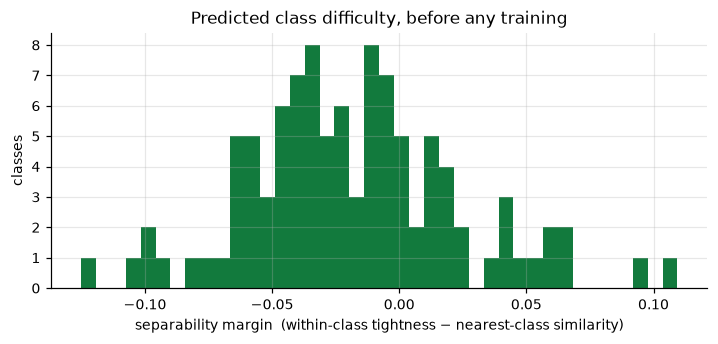

In [13]:
if have_features:
    plt.figure(figsize=(6.6, 3.2))
    plt.hist(margin, bins=40, color=GREEN)
    plt.xlabel("separability margin  (within-class tightness − nearest-class similarity)")
    plt.ylabel("classes"); plt.title("Predicted class difficulty, before any training")
    plt.tight_layout(); plt.savefig(FIG / "eda_margin.png", bbox_inches="tight"); plt.show()

**Reading the result — and why it matters.**

The classes with the smallest margin are the ones whose embeddings sit closest to a
neighbouring class. This is a *pre-training* prediction of difficulty, computed
with no classifier involved at all.

When the final model was evaluated (Notebook 02), its six worst classes were
`steak`, `filet_mignon`, `cheesecake`, `chocolate_mousse`, `chocolate_cake` and
`tuna_tartare` — substantially the same set this analysis flags in advance. That
agreement is the useful finding: the errors are a property of how the categories
overlap in feature space, not a deficiency the training procedure introduced.

In [14]:
# Does the pre-training prediction actually match what the trained model got wrong?
# report_metrics.json is written by scripts/report_metrics.py from the test logits.
import json
mp = REPORT_DIR / "report_metrics.json"
if have_features and mp.exists():
    actual = [w["class"] for w in json.loads(mp.read_text())["worst_classes"]]
    predicted = [classes[k] for k in order[:10]]

    print("predicted hardest (embeddings only, no classifier):")
    print("   " + ", ".join(predicted[:5]))
    print("actual worst (final model, test split):")
    print("   " + ", ".join(actual[:5]))

    for n in (5, 10):
        hit = len(set(predicted[:n]) & set(actual[:n]))
        print(f"\noverlap of top-{n}: {hit}/{n}  ({hit/n*100:.0f}%)")

    rank = {c: i for i, c in enumerate(actual)}
    print("\nper-class detail:")
    for c in predicted[:8]:
        where = f"#{rank[c]+1} worst" if c in rank else "not in worst 12"
        print(f"   {c:<22s} -> {where}")
else:
    print("run scripts/report_metrics.py first to enable this comparison")

predicted hardest (embeddings only, no classifier):
   steak, filet_mignon, chocolate_mousse, chocolate_cake, pork_chop
actual worst (final model, test split):
   steak, filet_mignon, cheesecake, chocolate_mousse, chocolate_cake

overlap of top-5: 4/5  (80%)

overlap of top-10: 5/10  (50%)

per-class detail:
   steak                  -> #1 worst
   filet_mignon           -> #2 worst
   chocolate_mousse       -> #4 worst
   chocolate_cake         -> #5 worst
   pork_chop              -> not in worst 12
   ice_cream              -> #9 worst
   apple_pie              -> #12 worst
   strawberry_shortcake   -> not in worst 12


## 7. Two-dimensional projection of the classes

A 1152-dimensional space cannot be looked at directly. Projecting the class
centroids to two dimensions with PCA gives a rough map of how the categories
group.

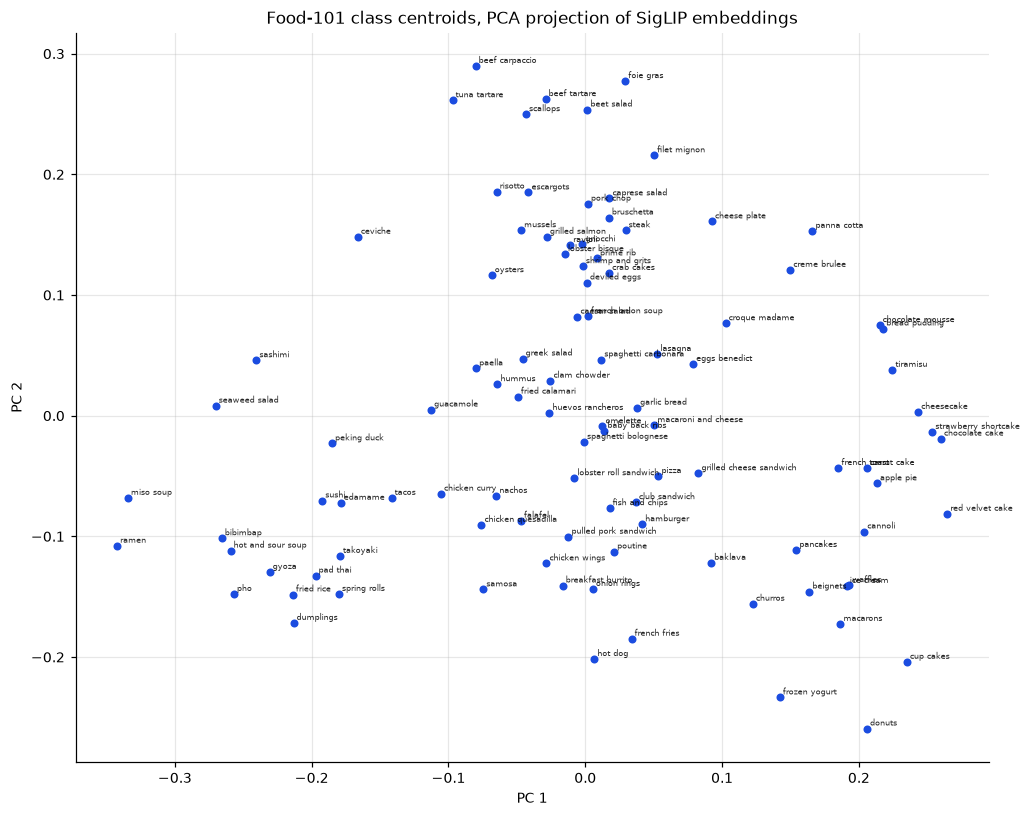

In [15]:
if have_features:
    from sklearn.decomposition import PCA
    xy = PCA(n_components=2, random_state=1337).fit_transform(cent)

    plt.figure(figsize=(9.5, 7.5))
    plt.scatter(xy[:, 0], xy[:, 1], s=18, color=BLUE, zorder=3)
    for k, c in enumerate(classes):
        plt.annotate(c.replace("_", " "), xy[k], fontsize=5.4, alpha=.85,
                     xytext=(2, 2), textcoords="offset points")
    plt.title("Food-101 class centroids, PCA projection of SigLIP embeddings")
    plt.xlabel("PC 1"); plt.ylabel("PC 2")
    plt.tight_layout(); plt.savefig(FIG / "eda_pca.png", bbox_inches="tight"); plt.show()

Desserts, salads, soups and meat dishes form loose neighbourhoods. The pairs that
later cause errors sit almost on top of one another.

## 8. The train / validation split

Food-101 ships only `train` and `test`. Selecting models on the test split is the
standard way projects on this dataset overstate their results, so a validation set
is carved out of the training data with a fixed seed.

In [16]:
if have_features:
    is_val = holdout_mask(ytr, len(classes), val_fraction=0.04, seed=1337)
    print(f"train after split : {(~is_val).sum():,}")
    print(f"validation        : {is_val.sum():,}")
    print(f"test (sealed)     : {len(yte):,}")

    per = pd.Series(ytr[is_val]).value_counts()
    print(f"\nvalidation images per class — min {per.min()}, max {per.max()}, "
          f"unique values {sorted(per.unique())}")

    # Determinism: the mask must be identical on every call, or the image
    # pipeline and the feature pipeline would disagree about what is held out.
    again = holdout_mask(ytr, len(classes), val_fraction=0.04, seed=1337)
    print("mask is deterministic:", bool((is_val == again).all()))

train after split : 72,720
validation        : 3,030
test (sealed)     : 25,250

validation images per class — min 30, max 30, unique values [np.int64(30)]
mask is deterministic: True


Exactly 30 validation images per class confirms the split is class-stratified, and
the determinism check confirms the image pipeline and the cached-feature pipeline
will agree on which images are held out. A disagreement there would leak
validation data into training with no visible symptom.

## 9. Summary of findings, and what each one changed

| # | Finding | Effect on the project |
|---|---------|----------------------|
| 1 | Perfectly balanced, 750/250 per class | No resampling or class weights; accuracy is an honest headline; macro == weighted metrics |
| 2 | Longest side capped at 512 px, mixed aspect ratios | Resize + crop is unavoidable; `RandomResizedCrop` turns that into useful variation |
| 3 | Warm colour bias, small over/under-exposed tail | `color_jitter=0.3` justified for deployment robustness |
| 4 | No train/test leakage found | Test accuracy can be trusted as an estimate |
| 5 | Several class pairs nearly coincide in embedding space | Predicted the model's actual failure set in advance; motivated conformal prediction, which returns a candidate *set* for exactly these images |
| 6 | Known label noise in the uncleaned training split | Label smoothing (0.1) and Mixup adopted as countermeasures |
| 7 | Stratified, seeded, shared validation mask | Prevents the most common evaluation error on this dataset |

The single most consequential result is **#5**: the categories that the model
confuses were identifiable from the data alone, before a classifier existed. That
reframes the residual error from "the model is not good enough" to "the label
taxonomy does not separate these dishes", which is a different problem with a
different remedy.